In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

print(tf.config.list_physical_devices('GPU'))

# Dataset path
file_path = '/content/drive/MyDrive/blood'


[]


Classes: ['AB+', 'B+', 'O+', 'B-', 'AB-', 'A+', 'O-', 'A-']


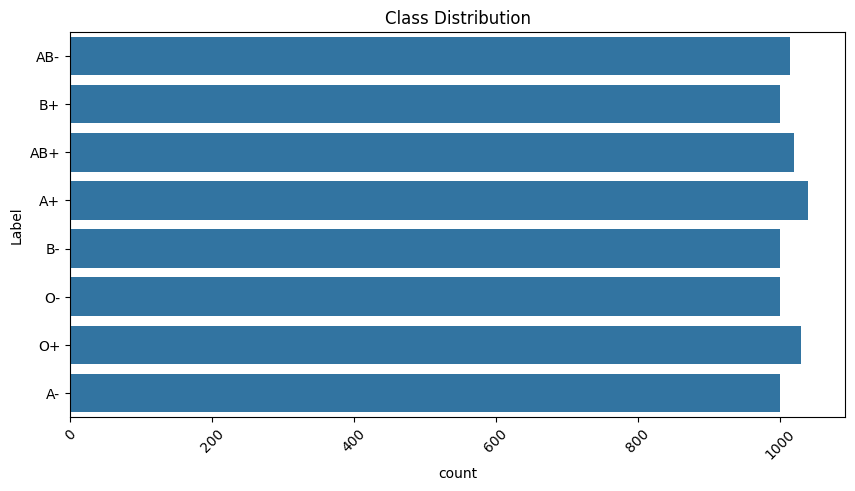

In [ ]:
# List blood group folders
name_class = os.listdir(file_path)
print("Classes:", name_class)

# Get image file paths
filepaths = list(glob.glob(file_path + '/**/*.*'))
labels = [os.path.basename(os.path.dirname(path)) for path in filepaths]

# Create DataFrame
data = pd.DataFrame({'Filepath': filepaths, 'Label': labels})
data = data.sample(frac=1).reset_index(drop=True)

# Visualize class distribution
plt.figure(figsize=(10,5))
sns.countplot(data['Label'])
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()


In [ ]:
train, test = train_test_split(data, test_size=0.2, stratify=data["Label"], random_state=42)

train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_dataframe(
    train, x_col='Filepath', y_col='Label',
    target_size=(224, 224), class_mode='categorical',
    batch_size=32, shuffle=True, seed=42)

valid_data = test_gen.flow_from_dataframe(
    test, x_col='Filepath', y_col='Label',
    target_size=(224, 224), class_mode='categorical',
    batch_size=32, shuffle=False)


Found 6484 validated image filenames belonging to 8 classes.
Found 1621 validated image filenames belonging to 8 classes.


In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model
base_model.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(8, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,587,976 (9.87 MB)

 Trainable params: 329,992 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=20
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 2438s 12s/step - accuracy: 0.2584 - loss: 2.0108 - val_accuracy: 0.4639 - val_loss: 1.3631
Epoch 2/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 506s 2s/step - accuracy: 0.4400 - loss: 1.4215 - val_accuracy: 0.5194 - val_loss: 1.2261
Epoch 3/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 504s 2s/step - accuracy: 0.4926 - loss: 1.2870 - val_accuracy: 0.5713 - val_loss: 1.1248
Epoch 4/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 491s 2s/step - accuracy: 0.5494 - loss: 1.1565 - val_accuracy: 0.5891 - val_loss: 1.0689
Epoch 5/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 433s 2s/step - accuracy: 0.5845 - loss: 1.1130 - val_accuracy: 0.6095 - val_loss: 1.0216
Epoch 6/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 509s 3s/step - accuracy: 0.5924 - loss: 1.0674 - val_accuracy: 0.6262 - val_loss: 0.9782
Epoch 7/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 511s 3s/step - accuracy: 0.6148 - loss: 1.0037 - val_accuracy: 0.6360 - val_loss: 0.9490
Epoch 8/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 507s 2s/step - accuracy: 0.6334 - loss: 0.9432 - val_ac

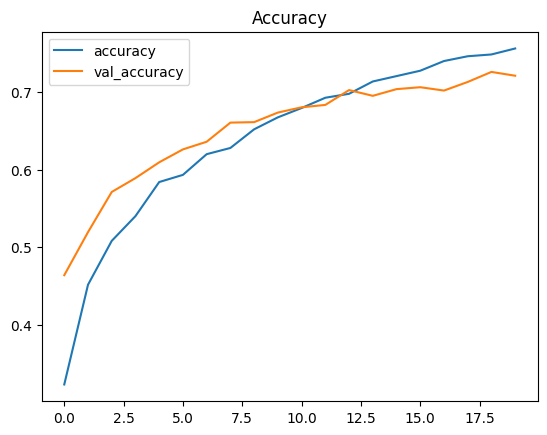

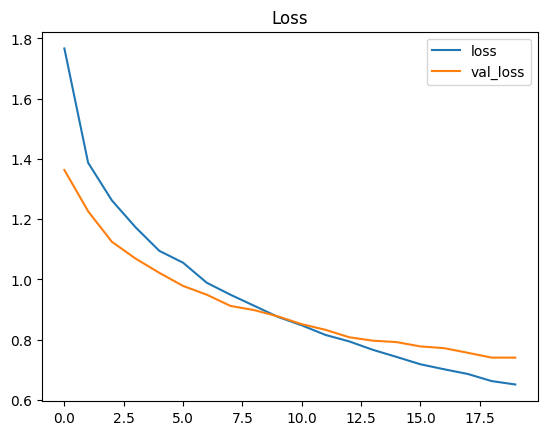

In [ ]:
pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot(title="Accuracy")
plt.show()
pd.DataFrame(history.history)[['loss','val_loss']].plot(title="Loss")
plt.show()


In [ ]:
# Evaluation
loss, acc = model.evaluate(valid_data, verbose=0)
print(f"Test Accuracy: {acc*100:.2f}%")

# Predict
pred = model.predict(valid_data)
pred_classes = np.argmax(pred, axis=1)

# Reverse class index
labels_dict = train_data.class_indices
labels_rev = dict((v, k) for k, v in labels_dict.items())

pred_labels = [labels_rev[i] for i in pred_classes]
true_labels = list(test['Label'])

# Classification report
print(classification_report(true_labels, pred_labels))


Test Accuracy: 72.12%
51/51 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step
              precision    recall  f1-score   support

          A+       0.84      0.84      0.84       208
          A-       0.69      0.66      0.67       200
         AB+       0.69      0.74      0.71       204
         AB-       0.59      0.84      0.69       203
          B+       0.73      0.58      0.65       200
          B-       0.85      0.81      0.83       200
          O+       0.72      0.72      0.72       206
          O-       0.74      0.57      0.65       200

    accuracy                           0.72      1621
   macro avg       0.73      0.72      0.72      1621
weighted avg       0.73      0.72      0.72      1621



Saving augmented_cluster_0_16.BMP to augmented_cluster_0_16.BMP
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


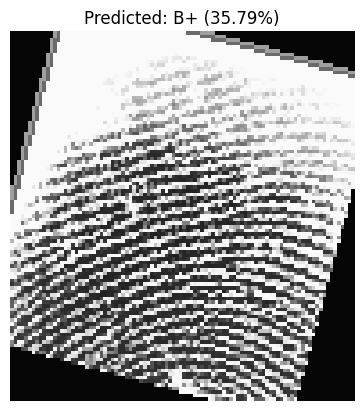

In [ ]:
# from tensorflow.keras.models import load_model
# from tensorflow.keras.preprocessing import image

# # Load saved model
# model = load_model("mobilenet_blood_group_model.keras")

# # Label mapping
# labels = {'A+': 0, 'A-': 1, 'AB+': 2, 'AB-': 3, 'B+': 4, 'B-': 5, 'O+': 6, 'O-': 7}
# labels = dict((v, k) for k, v in labels.items())

# # Load and predict
# img_path = '/content/drive/MyDrive/fingerprint-based-blood-group-detection/dataset/dataset_blood_group/AB+/cluster_4_1016.BMP'
# img = image.load_img(img_path, target_size=(224, 224))
# x = image.img_to_array(img)
# x = np.expand_dims(x, axis=0)
# x = preprocess_input(x)

# result = model.predict(x)
# pred_idx = np.argmax(result)
# pred_label = labels[pred_idx]
# confidence = result[0][pred_idx] * 100

# # Display
# plt.imshow(img)
# plt.axis('off')
# plt.title(f"Predicted: {pred_label} ({confidence:.2f}%)")
# plt.show()
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet import preprocess_input
from google.colab import files
import io
from PIL import Image, ImageEnhance

# Load model
model = load_model("mobilenet_blood_group_model.keras")

# Label mapping
labels = {'A+': 0, 'A-': 1, 'AB+': 2, 'AB-': 3, 'B+': 4, 'B-': 5, 'O+': 6, 'O-': 7}
labels = dict((v, k) for k, v in labels.items())

# Function to preprocess image
def preprocess_img(img):
    img_resized = img.resize((224, 224))
    x = image.img_to_array(img_resized)
    x = np.expand_dims(x, axis=0)
    return preprocess_input(x)

# Function for test-time augmentation (TTA)
def tta_predict(img):
    images = [img, img.transpose(Image.FLIP_LEFT_RIGHT)]  # original + flipped

    # Slight brightness adjustments
    enhancer = ImageEnhance.Brightness(img)
    images.append(enhancer.enhance(1.1))
    images.append(enhancer.enhance(0.9))

    # Predict on all versions
    preds = []
    for im in images:
        x = preprocess_img(im)
        preds.append(model.predict(x)[0])
    return np.mean(preds, axis=0)  # average prediction

# Upload image
uploaded = files.upload()

for filename in uploaded.keys():
    img = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')

    # Predict with TTA
    final_pred = tta_predict(img)
    pred_idx = np.argmax(final_pred)
    pred_label = labels[pred_idx]
    confidence = final_pred[pred_idx] * 100

    # Display result
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {pred_label} ({confidence:.2f}%)")
    plt.show()